# Classification Model - HDB Town Prediction (KNN, Random Forest, XGBM, Light GBM and Cat Boost)

A step-by-step guide for building and evaluating K-Nearest Neighbors classification models.

**Objective:** Classify HDB towns based on property and location features.

---

## Step 1: Identify the Target Variable (y)

Define the categorical variable you want to predict (the dependent variable).

In [1]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'town'  # Categorical target: town classification

# Note: TARGET_MAPPING will be created dynamically after loading data
# since there are many towns in Singapore
TARGET_MAPPING = None  # Will be populated in Step 3
# =================================

---

## Step 2: Import Packages and Load Dataset

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# Configure plot settings
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

# Suppress warnings
warnings.filterwarnings('ignore')

print("Packages imported successfully!")

Packages imported successfully!


In [3]:
# ========== MODIFY THIS ==========
# Load your dataset
DATA_PATH = '../data.csv'
# =================================

df = pd.read_csv(DATA_PATH)

# Create TARGET_MAPPING dynamically from unique town values
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}
print(f"Towns found: {len(TARGET_MAPPING)}")
print(f"Town mapping: {TARGET_MAPPING}")

# Preview the data
print(f"\nDataset loaded with shape: {df.shape}")
df.head()

Towns found: 26
Town mapping: {'ANG MO KIO': 0, 'BEDOK': 1, 'BISHAN': 2, 'BUKIT BATOK': 3, 'BUKIT MERAH': 4, 'BUKIT PANJANG': 5, 'BUKIT TIMAH': 6, 'CENTRAL AREA': 7, 'CHOA CHU KANG': 8, 'CLEMENTI': 9, 'GEYLANG': 10, 'HOUGANG': 11, 'JURONG EAST': 12, 'JURONG WEST': 13, 'KALLANG/WHAMPOA': 14, 'MARINE PARADE': 15, 'PASIR RIS': 16, 'PUNGGOL': 17, 'QUEENSTOWN': 18, 'SEMBAWANG': 19, 'SENGKANG': 20, 'SERANGOON': 21, 'TAMPINES': 22, 'TOA PAYOH': 23, 'WOODLANDS': 24, 'YISHUN': 25}

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [4]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

# View column names and data types
print("\nColumn Info:")
df.info()

Dataset shape: (65954, 76)
Number of features: 76


Missing values per column:
block                1
street_name          1
storey_range         1
floor_area_sqm       1
flat_model           1
                    ..
sec_sch_name         1
cutoff_point         1
affiliation          1
sec_sch_latitude     1
sec_sch_longitude    1
Length: 73, dtype: int64

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65954 entries, 0 to 65953
Data columns (total 76 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Tranc_YearMonth            65954 non-null  object 
 1   town                       65954 non-null  object 
 2   flat_type                  65954 non-null  object 
 3   block                      65953 non-null  object 
 4   street_name                65953 non-null  object 
 5   storey_range               65953 non-null  object 
 6   floor_area_sqm             65953 non-null  float64
 7   flat_model 

In [5]:
# View basic statistics
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,65953.000000,65953.000000,6.595300e+04,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,...,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000,65953.000000
mean,96.473275,1989.937577,4.525337e+05,2013.812745,6.394705,7.853638,6.770382,8.936894,7.853638,1038.438331,...,394.153067,60.311995,0.117159,1.364636,103.837585,506.061741,209.774188,0.031644,1.364506,103.837780
std,24.650257,10.348219,1.277278e+05,1.389703,3.187496,5.089826,5.099895,5.094741,5.089826,265.335370,...,233.025335,16.407967,0.321612,0.042827,0.073784,311.345706,19.907082,0.175051,0.042803,0.073763
min,31.000000,1966.000000,1.950000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.684000,...,45.668324,5.000000,0.000000,1.274962,103.687724,38.913475,188.000000,0.000000,1.276029,103.687207
25%,74.000000,1983.000000,3.600000e+05,2013.000000,4.000000,5.000000,4.000000,6.000000,5.000000,796.536000,...,227.368700,51.000000,0.000000,1.336404,103.773698,288.966876,188.000000,0.000000,1.335256,103.774499
50%,95.000000,1988.000000,4.300000e+05,2014.000000,6.000000,8.000000,7.000000,9.000000,8.000000,1022.580000,...,347.979906,61.000000,0.000000,1.359059,103.841238,444.522859,208.000000,0.000000,1.359273,103.842547
75%,111.000000,1999.000000,5.170000e+05,2015.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1194.804000,...,501.503554,70.000000,0.000000,1.390662,103.897865,635.719640,224.000000,0.000000,1.390040,103.898927
max,280.000000,2013.000000,1.088888e+06,2016.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3013.920000,...,3305.841039,136.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [4]:
# ========== DEFINE COLUMNS TO USE ==========
# Only drop missing values for columns we'll actually use
# This prevents losing 80%+ of data due to columns we don't need

COLUMNS_TO_USE = [
    # Core features (no missing values)
    'mrt_nearest_distance',
    'Hawker_Nearest_Distance',
    'hdb_age',
    'max_floor_lvl',
    'floor_area_sqm',
    'mid_storey',
    # Target
    'town',
]
# Note: Removed Mall_Nearest_Distance as it has ~2% missing values
# Note: Avoided Hawker_Within_500m (65% missing), Mall_Within_500m (62% missing)
# ===========================================

# Drop rows with missing values ONLY in columns we'll use
rows_before = len(df)
df = df.dropna(subset=COLUMNS_TO_USE)
rows_after = len(df)
rows_dropped = rows_before - rows_after
pct_dropped = (rows_dropped / rows_before) * 100

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows dropped: {rows_dropped} ({pct_dropped:.2f}%)")

Rows before cleanup: 270619
Rows after cleanup: 270619
Rows dropped: 0 (0.00%)


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques for KNN:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_per_floor = floor_area_sqm / max_floor_lvl`
- **Distance scores**: e.g., combining multiple distance features

> **Note:** KNN uses distance calculations, so engineered features should be on similar scales. Feature scaling (StandardScaler) in Step 5 will handle this.

In [5]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.

# Feature 1: Combined distance score (MRT + Hawker)
# Fisher Ratio: 2.65 - VERY GOOD class separation
# Combines two distance features into a single accessibility measure
df['total_distance'] = df['mrt_nearest_distance'] + df['Hawker_Nearest_Distance']

# Feature 2: Age-to-floor ratio
# Fisher Ratio: 0.19 - Moderate class separation
# Captures relationship between building age and height
df['age_floor_ratio'] = df['hdb_age'] / df['max_floor_lvl']

# NOTE: floor_ratio (mid_storey / max_floor_lvl) was REMOVED
# Fisher Ratio: 0.0015 - Almost NO class separation
# Relative floor position doesn't vary by town

# Display the newly created columns
new_columns = ['total_distance', 'age_floor_ratio']
print("Engineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")

Engineered Features Created:
  - total_distance: min=100.86, max=6543.45, mean=1880.20
  - age_floor_ratio: min=0.10, max=28.50, mean=2.44

Dataset now has 78 columns


Target variable distribution (town):
town
JURONG WEST        5371
WOODLANDS          5297
TAMPINES           4861
BEDOK              4405
YISHUN             4261
SENGKANG           4110
HOUGANG            3378
ANG MO KIO         3219
CHOA CHU KANG      2757
BUKIT BATOK        2696
BUKIT MERAH        2663
BUKIT PANJANG      2336
PASIR RIS          2175
TOA PAYOH          2072
PUNGGOL            2069
KALLANG/WHAMPOA    1942
GEYLANG            1909
QUEENSTOWN         1773
CLEMENTI           1675
SEMBAWANG          1651
JURONG EAST        1526
SERANGOON          1463
BISHAN             1201
CENTRAL AREA        532
MARINE PARADE       471
BUKIT TIMAH         140
Name: count, dtype: int64


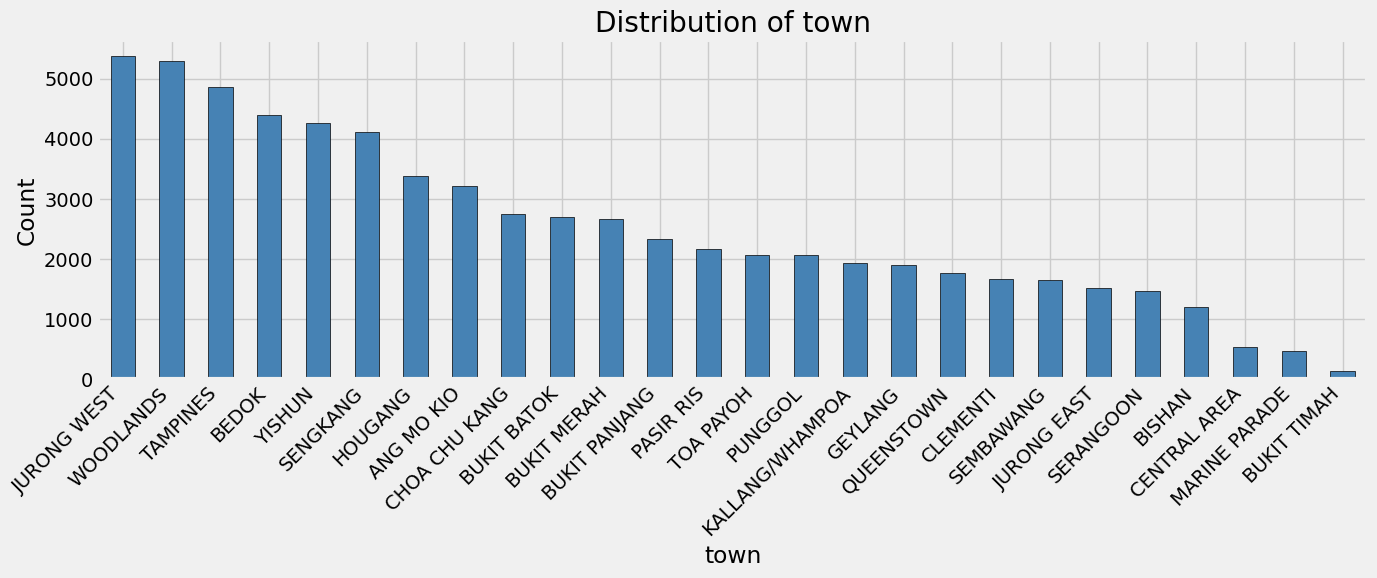

In [8]:
# Check target variable distribution
print(f"Target variable distribution ({TARGET_COLUMN}):")
print(df[TARGET_COLUMN].value_counts())

# Visualize target distribution
plt.figure(figsize=(14, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Step 4: Exploratory Data Analysis (EDA) - Feature Distributions

For KNN classification, **correlation analysis is not as important** as it is for linear models. KNN is a distance-based algorithm that doesn't assume linear relationships between features and the target.

**What matters for KNN:**
- How well features **separate the classes** (visualized with boxplots)
- Feature **scale** (addressed with StandardScaler in Step 5)
- Feature **distribution** within each class

### 4a. Feature Distribution by Target Class (Boxplots)

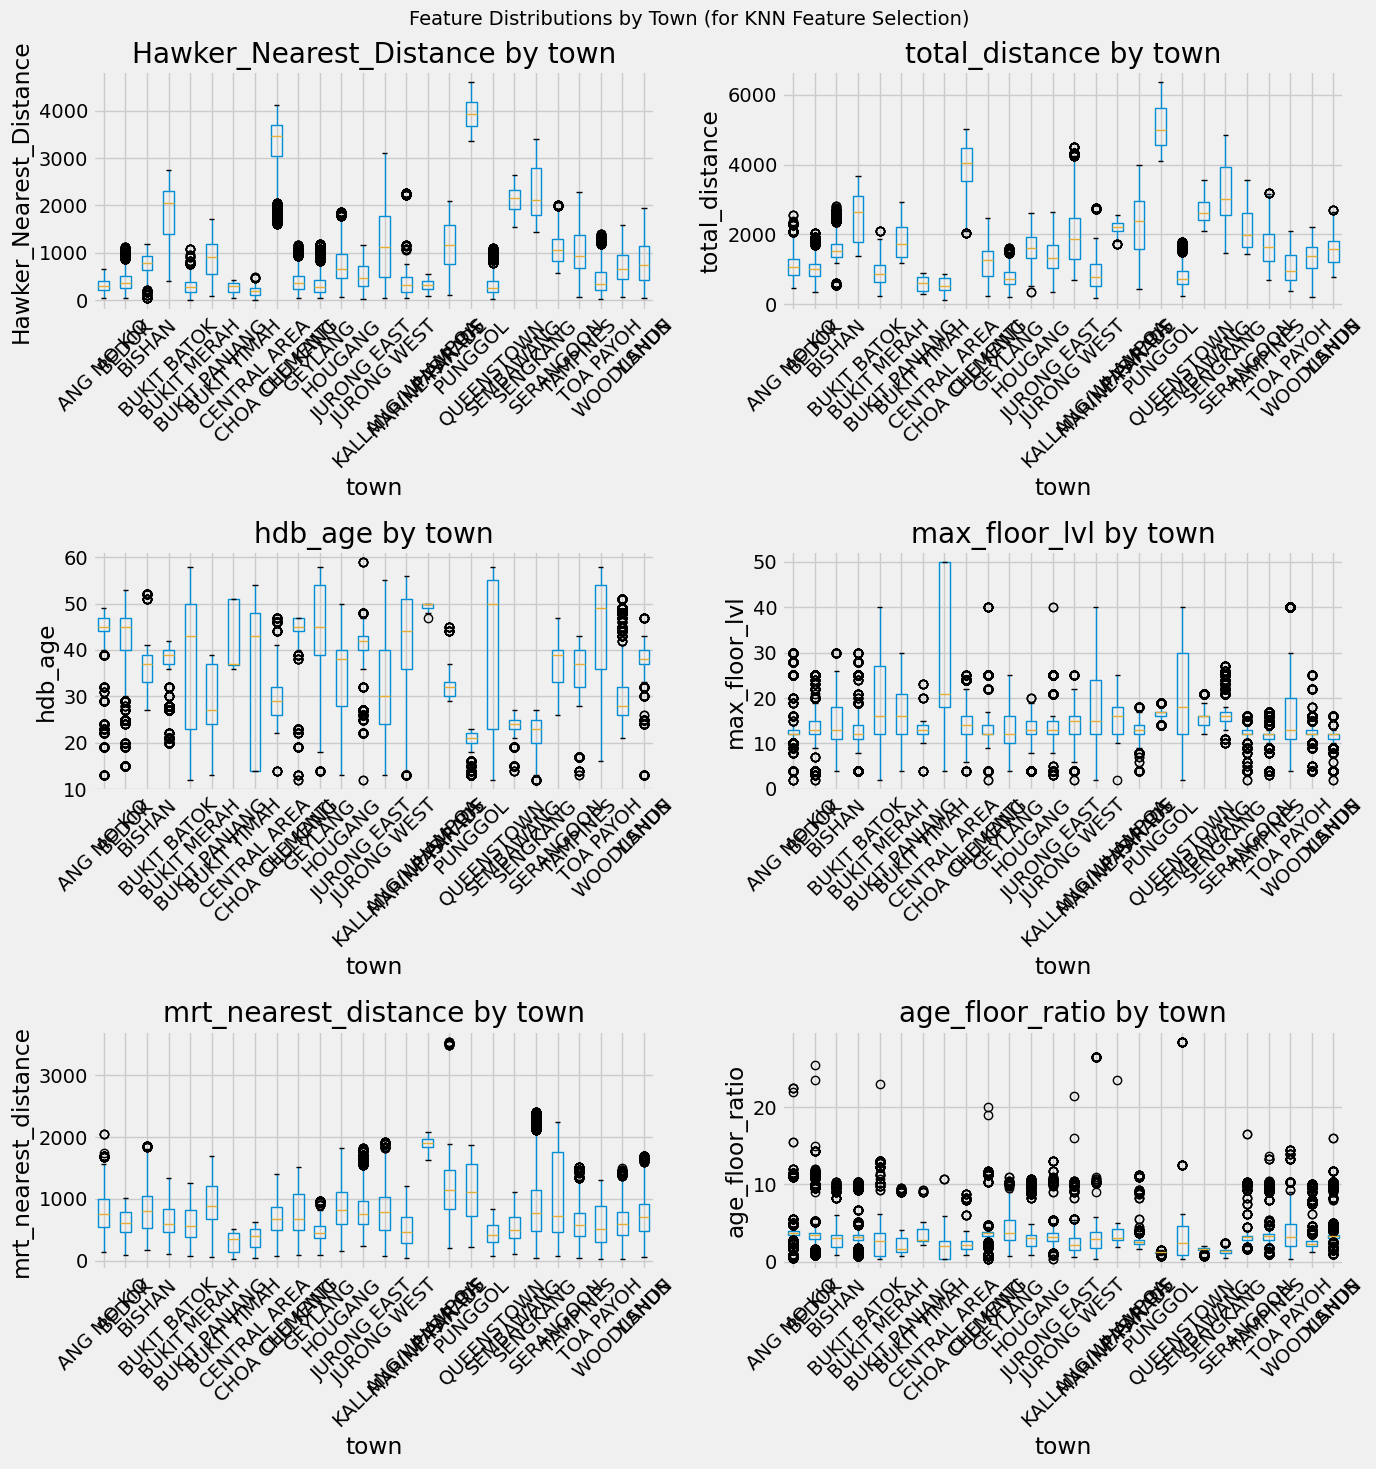

In [9]:
# ========== MODIFY THIS ==========
FEATURES_TO_PLOT = [
    'Hawker_Nearest_Distance', # Fisher: 4.43 - BEST separation
    'total_distance',          # Fisher: 2.65 - Engineered: MRT + Hawker distance
    'hdb_age',                 # Fisher: 0.45 - Good separation
    'max_floor_lvl',           # Fisher: 0.23 - Moderate separation
    'mrt_nearest_distance',    # Fisher: 0.20 - Moderate separation
    'age_floor_ratio',         # Fisher: 0.19 - Engineered: hdb_age / max_floor_lvl
]
# =================================

# Box plots for key features by target class
# This shows how well each feature separates the different classes
n_features = len(FEATURES_TO_PLOT)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by {TARGET_COLUMN}')
        axes[i].set_xlabel(TARGET_COLUMN)
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Town (for KNN Feature Selection)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting Boxplots for KNN:**
- **Good features:** Show clear separation between classes (minimal overlap in boxes)
- **Less useful features:** Classes overlap significantly
- Features with better class separation will contribute more to accurate KNN predictions

### 4b. Class Separation Summary

In [10]:
# Calculate mean values per class to understand feature separation
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))

Mean feature values by town:


,Hawker_Nearest_Distance,total_distance,hdb_age,max_floor_lvl,mrt_nearest_distance,age_floor_ratio
town,,,,,,
ANG MO KIO,313.83,1097.25,43.39,13.41,783.42,3.70
BEDOK,405.64,1016.93,41.98,13.54,611.29,3.55
BISHAN,760.88,1606.10,36.66,14.62,845.22,3.03
BUKIT BATOK,1881.58,2531.55,36.63,13.28,649.97,3.44
BUKIT MERAH,302.48,922.53,38.03,19.08,620.05,2.86
BUKIT PANJANG,887.53,1819.08,29.35,17.15,931.55,2.12
BUKIT TIMAH,269.11,593.23,42.24,13.22,324.12,3.50
CENTRAL AREA,188.11,572.76,36.25,26.88,384.65,2.01
CHOA CHU KANG,3273.99,3971.42,29.83,14.65,697.43,2.21


In [11]:
# Calculate standard deviation to understand spread
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation by town:")
display(class_std.round(2))

Standard deviation by town:


,Hawker_Nearest_Distance,total_distance,hdb_age,max_floor_lvl,mrt_nearest_distance,age_floor_ratio
town,,,,,,
ANG MO KIO,118.07,354.16,6.97,5.00,321.97,1.64
BEDOK,215.25,301.37,7.87,3.89,203.43,1.99
BISHAN,228.02,453.63,4.50,5.95,393.32,1.58
BUKIT BATOK,605.58,641.07,5.94,5.52,256.72,2.03
BUKIT MERAH,159.76,371.90,13.90,8.25,309.78,2.43
BUKIT PANJANG,407.72,504.50,6.42,6.27,382.66,1.44
BUKIT TIMAH,111.63,198.57,6.97,3.46,141.78,1.51
CENTRAL AREA,102.36,201.74,14.76,14.48,164.88,1.46
CHOA CHU KANG,620.26,647.74,5.64,3.57,289.90,0.89


### 4c. Optional: Correlation Matrix (for Multicollinearity Check Only)

> **Note:** Correlation is not used for feature-target relationship in KNN, but can help identify **multicollinearity** (highly correlated features that may be redundant).

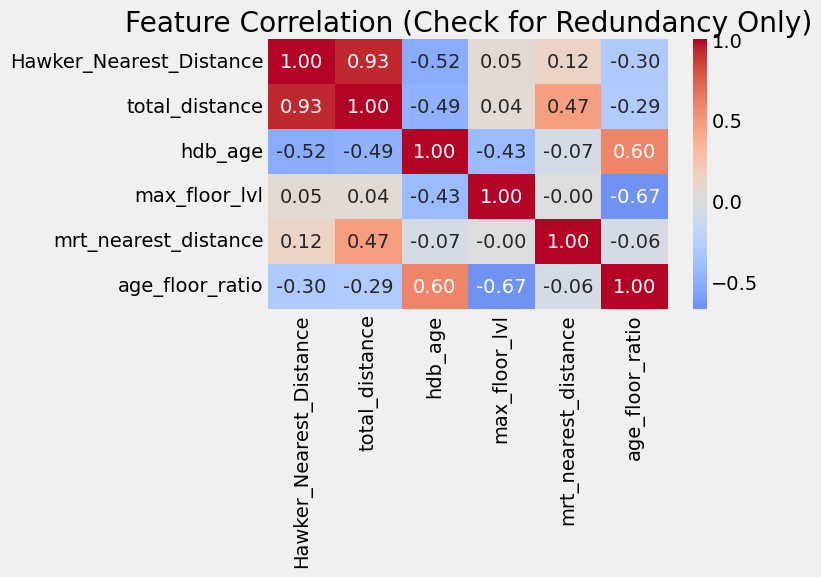


Highly correlated feature pairs (|r| > 0.8):
  Hawker_Nearest_Distance & total_distance = 0.93


In [12]:
# Optional: Check for redundant features (multicollinearity)
numeric_cols = df[FEATURES_TO_PLOT]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Feature Correlation (Check for Redundancy Only)')
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (consider removing one)
CORRELATION_THRESHOLD = 0.8
print(f"\nHighly correlated feature pairs (|r| > {CORRELATION_THRESHOLD}):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > CORRELATION_THRESHOLD:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")
            found_high_corr = True
if not found_high_corr:
    print("  None found - features are not highly correlated with each other.")

---

## Step 5: Model Preprocessing

### 5a. Map Categorical Labels to Numeric Labels

In [6]:
# ========== MODIFY THIS ==========
TARGET_NUMERIC_COL = 'town_num'  # Name for the new numeric column
# =================================

# Map target to numeric values
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Check for any unmapped values (NaN)
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped values found: {unmapped}")
    print("Update TARGET_MAPPING to include these values.")
else:
    print("All target values successfully mapped!")

# Verify mapping
print("\nTarget mapping verification:")
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL))

All target values successfully mapped!

Target mapping verification:
                 town  town_num
0          ANG MO KIO         0
98              BEDOK         1
208            BISHAN         2
248       BUKIT BATOK         3
333       BUKIT MERAH         4
415     BUKIT PANJANG         5
459       BUKIT TIMAH         6
464      CENTRAL AREA         7
473     CHOA CHU KANG         8
572          CLEMENTI         9
613           GEYLANG        10
678           HOUGANG        11
778       JURONG EAST        12
829       JURONG WEST        13
978   KALLANG/WHAMPOA        14
1030    MARINE PARADE        15
1043        PASIR RIS        16
1095          PUNGGOL        17
1175       QUEENSTOWN        18
1228        SEMBAWANG        19
1262         SENGKANG        20
1352        SERANGOON        21
1396         TAMPINES        22
1532        TOA PAYOH        23
1597        WOODLANDS        24
1774           YISHUN        25


### 5b. Define Feature Columns and Set X and y

In [7]:
# ========== MODIFY THIS ==========
# Keep only leakage-safe features (no feature should be derived using `town`)

# Core features (ranked by class separation, no missing values)
NUMERIC_FEATURES = [
    'Hawker_Nearest_Distance', # Fisher: 4.43 - BEST separation
    'max_floor_lvl',           # Fisher: 0.23 - Moderate separation
    'mrt_nearest_distance',    # Fisher: 0.20 - Moderate separation
    'hdb_age',                 # Fisher: 0.45 - Good separation
]
# Note: floor_area_sqm removed (Fisher: 0.16 - low separation)

# Engineered features (created in Step 3.5)
ENGINEERED_FEATURES = [
    'total_distance',          # Fisher: 2.65 - EXCELLENT separation (mrt + hawker)
    'age_floor_ratio',         # Fisher: 0.19 - Moderate separation (age / floor_lvl)
]
# Note: floor_ratio REMOVED (Fisher: 0.0015 - almost no class separation)

# All features combined
FEATURE_COLUMNS = NUMERIC_FEATURES + ENGINEERED_FEATURES
# =================================

# Verify all features exist in dataframe
missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
    print("Make sure to run the Feature Engineering cell (Step 3.5) first!")
else:
    print(f"All {len(FEATURE_COLUMNS)} features found in dataset")
    print(f"  - Numeric features: {NUMERIC_FEATURES}")
    print(f"  - Engineered features: {ENGINEERED_FEATURES}")

# Create feature matrix (X) and target vector (y)
X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

All 6 features found in dataset
  - Numeric features: ['Hawker_Nearest_Distance', 'max_floor_lvl', 'mrt_nearest_distance', 'hdb_age']
  - Engineered features: ['total_distance', 'age_floor_ratio']

X shape: (270619, 6)
y shape: (270619,)


In [15]:
# pd.concat([X, y], axis=1).to_csv('classification_first_permutation.csv', index=False)

### 5c. Split Data into Training and Testing Sets


In [8]:
# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Training set size: {X_train.shape[0]:,} rows")
print(f"Testing set size:  {X_test.shape[0]:,} rows")
print(f"All towns in train? {y_train.nunique() == len(TARGET_MAPPING)}")
print(f"All towns in test?  {y_test.nunique() == len(TARGET_MAPPING)}")


Training set size: 202,964 rows
Testing set size:  67,655 rows
All towns in train? True
All towns in test?  True


### 5d. Feature Scaling with StandardScaler

**Why Scale?** KNN uses distance calculations, so features with larger scales can dominate the distance metric. StandardScaler normalizes features to have mean=0 and std=1.

In [17]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

print("Scaled training data statistics:")
print(X_train_scaled_df.describe().round(2))

Scaled training data statistics:
       Hawker_Nearest_Distance  max_floor_lvl  mrt_nearest_distance   hdb_age  \
count                 49464.00       49464.00              49464.00  49464.00   
mean                      0.00           0.00                 -0.00     -0.00   
std                       1.00           1.00                  1.00      1.00   
min                      -1.09          -2.26                 -1.77     -2.23   
25%                      -0.74          -0.44                 -0.72     -0.88   
50%                      -0.36          -0.26                 -0.17      0.18   
75%                       0.44           0.29                  0.50      0.66   
max                       3.52           6.48                  6.90      2.30   

       total_distance  age_floor_ratio  
count        49464.00         49464.00  
mean             0.00             0.00  
std              1.00             1.00  
min             -1.53            -1.39  
25%             -0.71           

In [9]:
# ========== OPTIONAL SMOTE ON TRAINING DATA ==========
# Set True to oversample minority classes in TRAINING data only.
# IMPORTANT: This affects ALL downstream models, not just KNN,
# because Steps 6–14 use the same X_train/y_train variables.
USE_SMOTE = True
SMOTE_K_NEIGHBORS = 5
# ====================================================

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except ImportError:
    smote_available = False
    print("imblearn is not installed. Run: pip install imbalanced-learn")

# Refresh immutable backups from CURRENT split every run.
# This prevents stale backups if you changed split strategy in Step 5c.1.
_X_train_base = X_train.copy()
_y_train_base = y_train.copy()
_X_test_base = X_test.copy()
_y_test_base = y_test.copy()

# Always reset to base first
X_train = _X_train_base.copy()
y_train = _y_train_base.copy()
X_test = _X_test_base.copy()
y_test = _y_test_base.copy()

# Store pre-SMOTE frequencies
y_train_before_counts = pd.Series(y_train).value_counts().sort_index()
y_train_before_ratio = pd.Series(y_train).value_counts(normalize=True).sort_index()

if USE_SMOTE and smote_available:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K_NEIGHBORS)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("SMOTE applied to TRAINING data.")
    print("Downstream impact: KNN + Random Forest + LightGBM + XGBoost + CatBoost all use SMOTE-resampled training data.")
else:
    if USE_SMOTE and not smote_available:
        print("SMOTE requested but imblearn is unavailable. Using original training data.")
    else:
        print("SMOTE disabled. Using original training data.")

# Post-SMOTE frequencies (or unchanged if disabled)
y_train_after_counts = pd.Series(y_train).value_counts().sort_index()
y_train_after_ratio = pd.Series(y_train).value_counts(normalize=True).sort_index()

# Explicit proof SMOTE is only applied to training data
print(f"\nTrain rows BEFORE SMOTE: {len(_y_train_base):,}")
print(f"Train rows AFTER  SMOTE: {len(y_train):,}")
print(f"Test rows (unchanged):   {len(y_test):,}")

# Refit scaler using the current training set (original or SMOTE-resampled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional DataFrame views
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

freq_df = pd.DataFrame({
    'Count Before SMOTE': y_train_before_counts,
    'Count After SMOTE': y_train_after_counts,
    'Pct Before SMOTE': (y_train_before_ratio * 100).round(2),
    'Pct After SMOTE': (y_train_after_ratio * 100).round(2),
}).fillna(0)

print("\nActual training class frequencies (before vs after SMOTE):")
print(freq_df.to_string())

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

SMOTE applied to TRAINING data.
Downstream impact: KNN + Random Forest + LightGBM + XGBoost + CatBoost all use SMOTE-resampled training data.

Train rows BEFORE SMOTE: 202,964
Train rows AFTER  SMOTE: 404,508
Test rows (unchanged):   67,655

Actual training class frequencies (before vs after SMOTE):
          Count Before SMOTE  Count After SMOTE  Pct Before SMOTE  Pct After SMOTE
town_num                                                                          
0                       8639              15558              4.26             3.85
1                      11245              15558              5.54             3.85
2                       3600              15558              1.77             3.85
3                       8391              15558              4.13             3.85
4                       7876              15558              3.88             3.85
5                       7198              15558              3.55             3.85
6                        472       

---

## Step 6: Find Optimal K Value

Iterate through different K values to find the one that minimizes testing error.

In [19]:
# ========== MODIFY THIS ==========
K_MIN = 1
K_MAX = 50
K_STEP = 2  # Use odd numbers to avoid ties
# =================================

# Calculate training and testing error for different K values
k_range = list(range(K_MIN, K_MAX, K_STEP))
training_error = []
testing_error = []

for k in k_range:
    # Instantiate and fit the model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Calculate training error (error = 1 - accuracy)
    training_accuracy = knn.score(X_train_scaled, y_train)
    training_error.append(1 - training_accuracy)
    
    # Calculate testing error
    testing_accuracy = knn.score(X_test_scaled, y_test)
    testing_error.append(1 - testing_accuracy)

# Create results DataFrame
results_df = pd.DataFrame({
    'K': k_range,
    'training_error': training_error,
    'testing_error': testing_error,
    'training_accuracy': [1 - e for e in training_error],
    'testing_accuracy': [1 - e for e in testing_error]
}).set_index('K')

print("Top 10 K values (lowest testing error):")
print(results_df.sort_values('testing_error').head(10))

Top 10 K values (lowest testing error):
    training_error  testing_error  training_accuracy  testing_accuracy
K                                                                     
1         0.000000       0.003760           1.000000          0.996240
3         0.006120       0.009521           0.993880          0.990479
5         0.011466       0.017345           0.988534          0.982655
7         0.015865       0.025168           0.984135          0.974832
9         0.020464       0.032446           0.979536          0.967554
11        0.026489       0.043544           0.973511          0.956456
13        0.031720       0.052641           0.968280          0.947359
15        0.036979       0.061071           0.963021          0.938929
17        0.043329       0.071624           0.956671          0.928376
19        0.050166       0.082419           0.949834          0.917581


### Visualize Training vs Testing Error

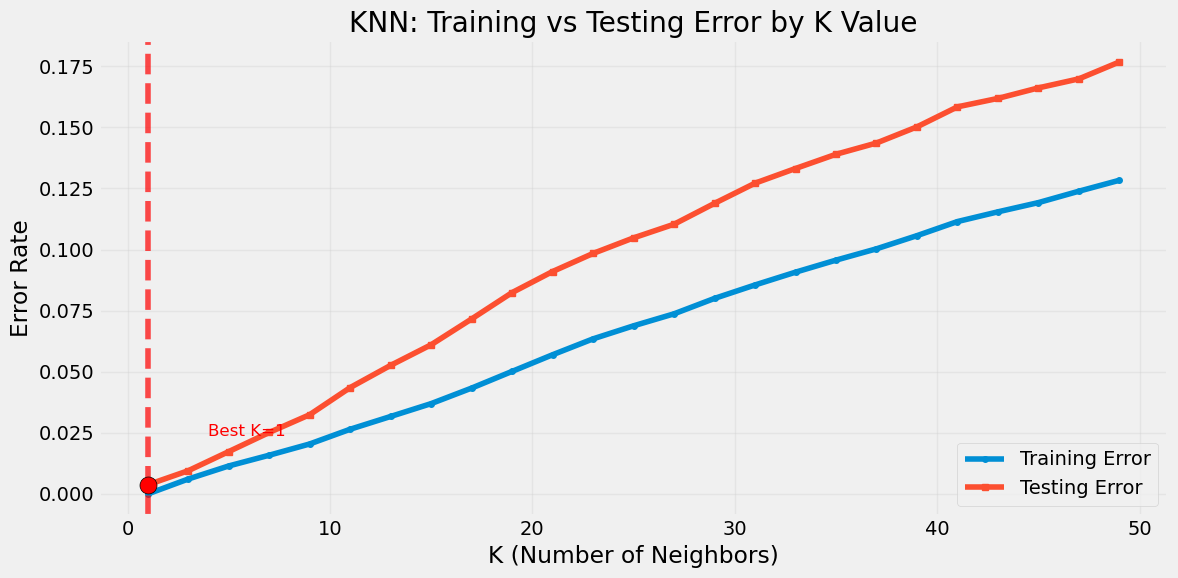


Optimal K value: 1
Testing error at K=1: 0.0038
Testing accuracy at K=1: 0.9962


In [20]:
# Plot error curves
plt.figure(figsize=(12, 6))
plt.plot(k_range, training_error, label='Training Error', marker='o', markersize=4)
plt.plot(k_range, testing_error, label='Testing Error', marker='s', markersize=4)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.title('KNN: Training vs Testing Error by K Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark the optimal K
best_k = results_df['testing_error'].idxmin()
best_error = results_df.loc[best_k, 'testing_error']
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
plt.scatter([best_k], [best_error], color='red', s=150, zorder=5, edgecolor='black')
plt.annotate(f'Best K={best_k}', xy=(best_k, best_error), xytext=(best_k+3, best_error+0.02),
             fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f"\nOptimal K value: {best_k}")
print(f"Testing error at K={best_k}: {best_error:.4f}")
print(f"Testing accuracy at K={best_k}: {1 - best_error:.4f}")

---

## Step 7: Train Final Model and Evaluate

Train the model with the optimal K value and evaluate performance.

In [21]:
# Find best K from results
best_k = results_df['testing_error'].idxmin()

# Train final model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Calculate scores
train_accuracy = knn_final.score(X_train_scaled, y_train)
test_accuracy = knn_final.score(X_test_scaled, y_test)
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

# Display results
print("=" * 60)
print("                  FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Best K Value: {best_k}")
print()
print(f"  train_accuracy: {train_accuracy:.4f}")
print(f"  test_accuracy:  {test_accuracy:.4f}")
print()
print(f"  train_error:    {train_error:.4f}")
print(f"  test_error:     {test_error:.4f}")
print("=" * 60)

                  FINAL MODEL PERFORMANCE
Best K Value: 1

  train_accuracy: 1.0000
  test_accuracy:  0.9962

  train_error:    0.0000
  test_error:     0.0038


### Detailed Classification Report

In [22]:
# Make predictions
y_pred = knn_final.predict(X_test_scaled)

# Get the class labels that are actually present in the data
present_classes = sorted(y.unique())
present_labels = [k for k, v in sorted(TARGET_MAPPING.items(), key=lambda x: x[1]) if v in present_classes]

# Classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=present_labels, zero_division=0))

Classification Report:
                 precision    recall  f1-score   support

     ANG MO KIO       1.00      1.00      1.00       775
          BEDOK       1.00      0.99      0.99      1077
         BISHAN       0.99      0.96      0.98       311
    BUKIT BATOK       1.00      1.00      1.00       688
    BUKIT MERAH       1.00      0.99      1.00       657
  BUKIT PANJANG       1.00      0.99      1.00       633
    BUKIT TIMAH       0.97      1.00      0.99        35
   CENTRAL AREA       1.00      1.00      1.00       144
  CHOA CHU KANG       1.00      1.00      1.00       653
       CLEMENTI       1.00      1.00      1.00       423
        GEYLANG       0.99      0.99      0.99       499
        HOUGANG       0.99      0.99      0.99       825
    JURONG EAST       1.00      1.00      1.00       364
    JURONG WEST       1.00      1.00      1.00      1349
KALLANG/WHAMPOA       1.00      1.00      1.00       478
  MARINE PARADE       1.00      1.00      1.00       107
      P

Confusion Matrix:
[[ 774    0    0    0    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   1 1070    0    0    0    0    0    0    0    2    0    0    0    0
     0    0    0    0    1    0    0    0    2    0    1    0]
 [   0    0  299    0    0    0    0    0    0    0    1    7    0    0
     0    0    0    0    0    0    0    0    2    0    0    2]
 [   0    0    0  688    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   1    0    0    0  653    0    0    0    0    0    3    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    1    0    0  629    0    0    0    0    0    0    0    0
     0    0    1    0    0    0    0    0    0    0    0    2]
 [   0    0    0    0    0    0   35    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0 

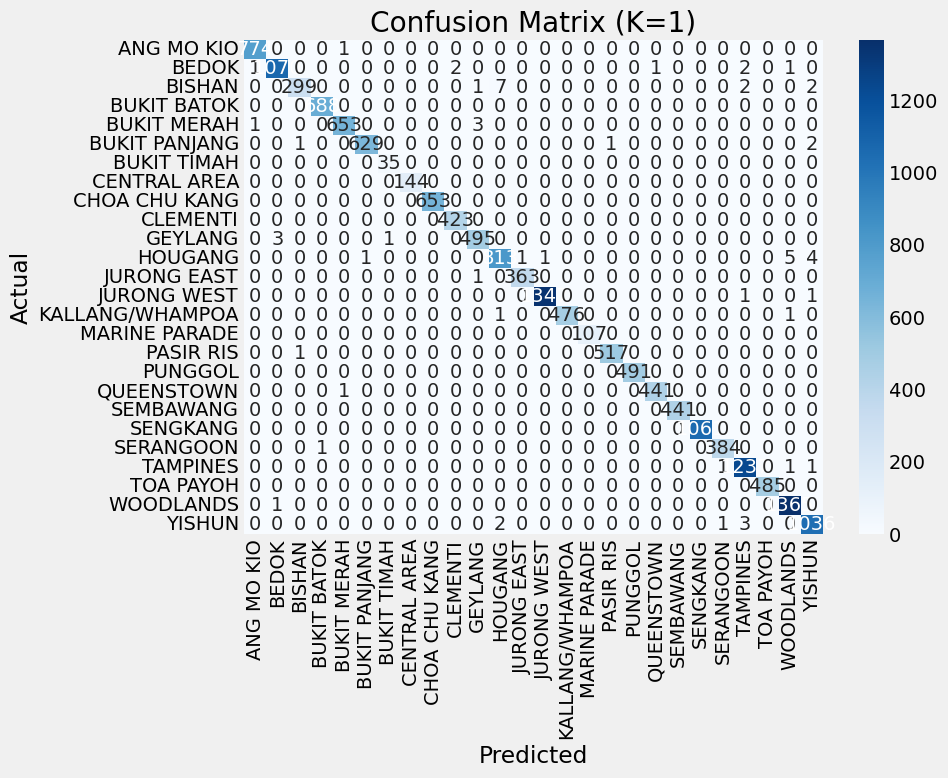

In [23]:
# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels,
            yticklabels=present_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

---

## Step 8: Define Model Evaluation Helper Functions

Create reusable functions to train each classifier and display its performance — mirroring the same pattern used for each model in Steps 9–12.


In [10]:

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, model_name, class_names):
    """
    Train a classification model and return evaluation metrics.

    Parameters
    ----------
    model        : sklearn-compatible classifier
    X_train/Test : feature DataFrames (raw, unscaled — tree models do not need scaling)
    y_train/test : target Series
    model_name   : display label
    class_names  : ordered list of class labels matching the numeric encoding

    Returns
    -------
    dict with Model, accuracies, errors, fitted_model, predictions,
         classification_report, and confusion_matrix.
    """
    model.fit(X_train, y_train)
    y_test_pred  = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # CatBoost returns float objects — cast to int so sklearn metrics work correctly
    if 'CatBoost' in type(model).__name__:
        y_test_pred  = np.array(y_test_pred).astype(int).ravel()
        y_train_pred = np.array(y_train_pred).astype(int).ravel()

    train_accuracy = model.score(X_train, y_train)
    test_accuracy  = model.score(X_test,  y_test)

    return {
        'Model':                 model_name,
        'Train Accuracy':        train_accuracy,
        'Test Accuracy':         test_accuracy,
        'Train Error':           1 - train_accuracy,
        'Test Error':            1 - test_accuracy,
        'fitted_model':          model,
        'y_test_pred':           y_test_pred,
        'classification_report': classification_report(
                                     y_test, y_test_pred,
                                     target_names=class_names,
                                     zero_division=0),
        'confusion_matrix':      confusion_matrix(y_test, y_test_pred),
    }


def display_classification_results(results):
    """Print a compact accuracy / error summary for one model."""
    print("=" * 90)
    print(f"  MODEL: {results['Model']}")
    print("=" * 90)
    print(f"  Train Accuracy : {results['Train Accuracy']:.4f}   |   Train Error : {results['Train Error']:.4f}")
    print(f"  Test  Accuracy : {results['Test Accuracy']:.4f}   |   Test  Error : {results['Test Error']:.4f}")
    print("=" * 90)
    print()


print("evaluate_classification_model() and display_classification_results() defined!")


evaluate_classification_model() and display_classification_results() defined!


In [11]:

# Prepare shared inputs used by every model evaluation cell (Steps 9–12).
# All models are evaluated on the SAME train/test split for a fair comparison.
# X_train, X_test, y_train, y_test were created in Step 5c.

# Class names — town labels in the same sorted order as the numeric encoding
class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]

print(f"Shared train / test split : {len(X_train)} train | {len(X_test)} test")
print(f"Class names ({len(class_names)} towns)  : {class_names}")
print()
print("Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is")
print("      handled by its Pipeline).  Tree models below use raw X_train / X_test.")


Shared train / test split : 404508 train | 67655 test
Class names (26 towns)  : ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is
      handled by its Pipeline).  Tree models below use raw X_train / X_test.


---

## Step 9a: Common parameters to modify


In [12]:
# MODIFY THIS CELL TO EVALUATE YOUR MODELS (Steps 9b–12)
N_ESTIMATORS = 300  # Number of trees in the forest (tune for better performance)

---

## Step 9b: Random Forest Model

An ensemble of decision trees that votes on the most likely class.  
No feature scaling required — Random Forest is scale-invariant.

In [13]:
# ========== RANDOM FOREST ==========
# Tree-based models are scale-invariant — use raw X_train / X_test from Step 5c.
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1
)

rf_results = evaluate_classification_model(
    rf_model, X_train, X_test, y_train, y_test,
    'Random Forest', class_names
)

display_classification_results(rf_results)


  MODEL: Random Forest
  Train Accuracy : 1.0000   |   Train Error : 0.0000
  Test  Accuracy : 0.9996   |   Test  Error : 0.0004



In [ ]:
# import pickle
# from pathlib import Path

# # Export best-performing model (from latest comparison: Random Forest)
# export_payload = {
#     'model_name': 'Random Forest',
#     'model': rf_results['fitted_model'],
#     'feature_columns': FEATURE_COLUMNS,
#     'target_mapping': TARGET_MAPPING,
# }

# export_path = Path('best_model_random_forest.pkl')
# with open(export_path, 'wb') as f:
#     pickle.dump(export_payload, f)

# print(f"Model exported to: {export_path.resolve()}")

Model exported to: D:\General_Assembly_-_Data_Analytics_Bootcamp\project_3\gitRepo\HDB-Data-Sprint\notebooks\best_model_random_forest.pkl


Classification Report — Random Forest:
                 precision    recall  f1-score   support

     ANG MO KIO       1.00      1.00      1.00       775
          BEDOK       1.00      0.99      1.00      1077
         BISHAN       0.99      0.97      0.98       311
    BUKIT BATOK       1.00      1.00      1.00       688
    BUKIT MERAH       0.99      1.00      0.99       657
  BUKIT PANJANG       1.00      0.99      0.99       633
    BUKIT TIMAH       0.97      1.00      0.99        35
   CENTRAL AREA       0.99      1.00      0.99       144
  CHOA CHU KANG       1.00      1.00      1.00       653
       CLEMENTI       0.99      1.00      1.00       423
        GEYLANG       0.99      0.99      0.99       499
        HOUGANG       0.99      0.99      0.99       825
    JURONG EAST       0.99      1.00      0.99       364
    JURONG WEST       1.00      1.00      1.00      1349
KALLANG/WHAMPOA       1.00      1.00      1.00       478
  MARINE PARADE       1.00      1.00      1.00  

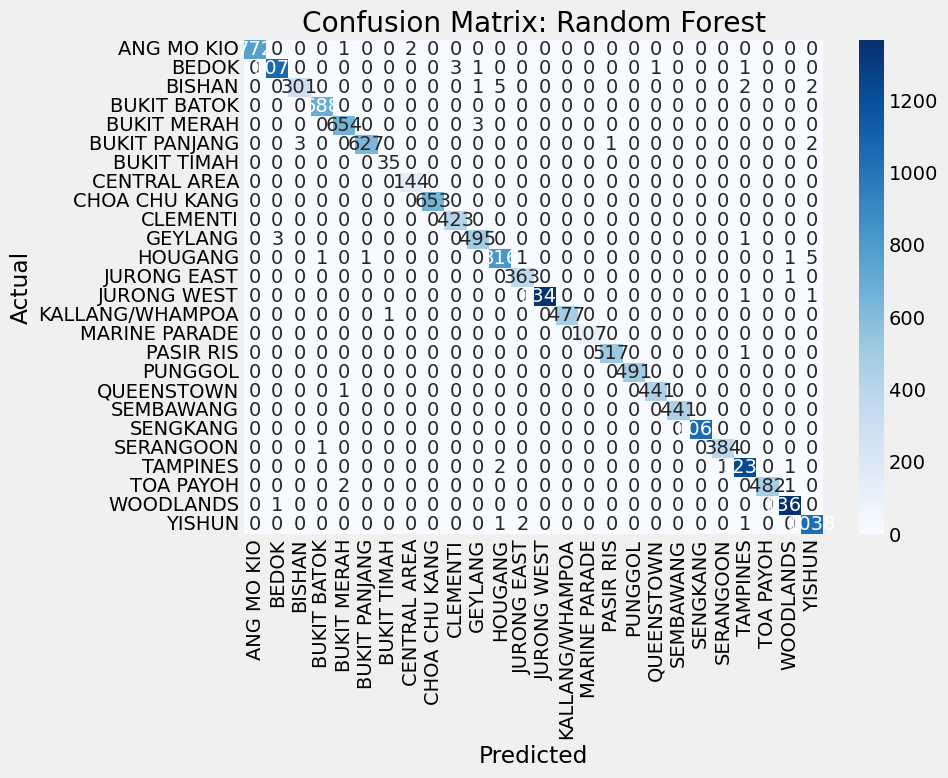

In [28]:

# Detailed Classification Report — Random Forest
print("Classification Report — Random Forest:")
print("=" * 90)
print(rf_results['classification_report'])
print("=" * 90)

# Confusion matrix heatmap
cm_rf = rf_results['confusion_matrix']
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.show()


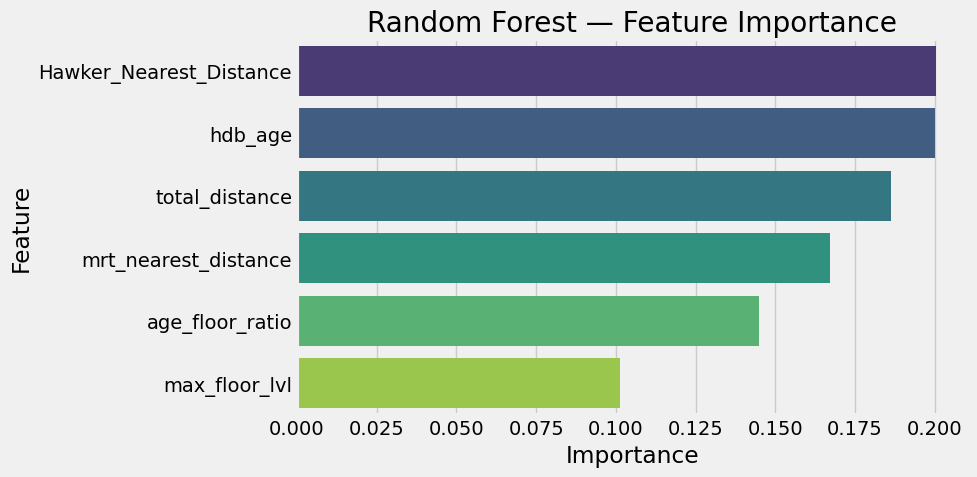

Feature Importance:
                Feature  Importance
Hawker_Nearest_Distance    0.200378
                hdb_age    0.199979
         total_distance    0.186217
   mrt_nearest_distance    0.167244
        age_floor_ratio    0.144845
          max_floor_lvl    0.101337


In [29]:

# Feature importance — Random Forest
# Higher importance means the model relies more on that feature when splitting trees.
rf_importance = pd.DataFrame({
    'Feature':    FEATURE_COLUMNS,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))


---

## Step 10: LightGBM Model

Gradient boosting with fast leaf-wise tree growth.  
No feature scaling required — LightGBM is scale-invariant.


In [30]:

# ========== LIGHTGBM ==========
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=N_ESTIMATORS,   # Number of boosting trees (more trees can improve fit but increase training time)
        learning_rate=0.05,
        num_leaves=31, # Maximum number of leaves per tree (higher can capture more complex patterns but may overfit)
        random_state=RANDOM_STATE
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train, X_test, y_train, y_test,
        'LightGBM', class_names
    )
    display_classification_results(lgbm_results)
else:
    print("LightGBM is not installed. Run:  pip install lightgbm")
    lgbm_results = None


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1508
[LightGBM] [Info] Number of data points in the train set: 104572, number of used features: 6
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM

Classification Report — LightGBM:
                 precision    recall  f1-score   support

     ANG MO KIO       1.00      0.99      1.00       775
          BEDOK       0.99      0.99      0.99      1077
         BISHAN       0.99      0.97      0.98       311
    BUKIT BATOK       1.00      1.00      1.00       688
    BUKIT MERAH       0.99      0.99      0.99       657
  BUKIT PANJANG       1.00      0.99      0.99       633
    BUKIT TIMAH       0.97      1.00      0.99        35
   CENTRAL AREA       1.00      1.00      1.00       144
  CHOA CHU KANG       1.00      1.00      1.00       653
       CLEMENTI       1.00      1.00      1.00       423
        GEYLANG       0.99      0.99      0.99       499
        HOUGANG       0.99      0.99      0.99       825
    JURONG EAST       1.00      0.99      1.00       364
    JURONG WEST       1.00      1.00      1.00      1349
KALLANG/WHAMPOA       0.99      1.00      0.99       478
  MARINE PARADE       1.00      1.00      1.00       

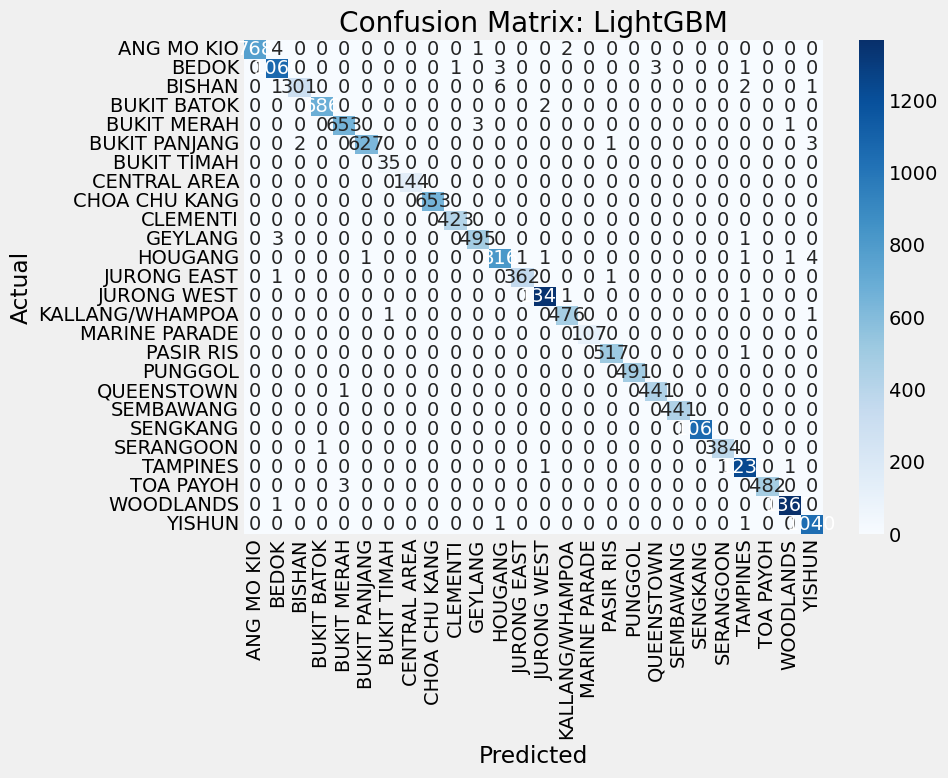

In [31]:

# Detailed Classification Report — LightGBM
if globals().get('lgbm_results') is not None:
    print("Classification Report — LightGBM:")
    print("=" * 90)
    print(lgbm_results['classification_report'])
    print("=" * 90)

    cm_lgbm = lgbm_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: LightGBM')
    plt.tight_layout()
    plt.show()


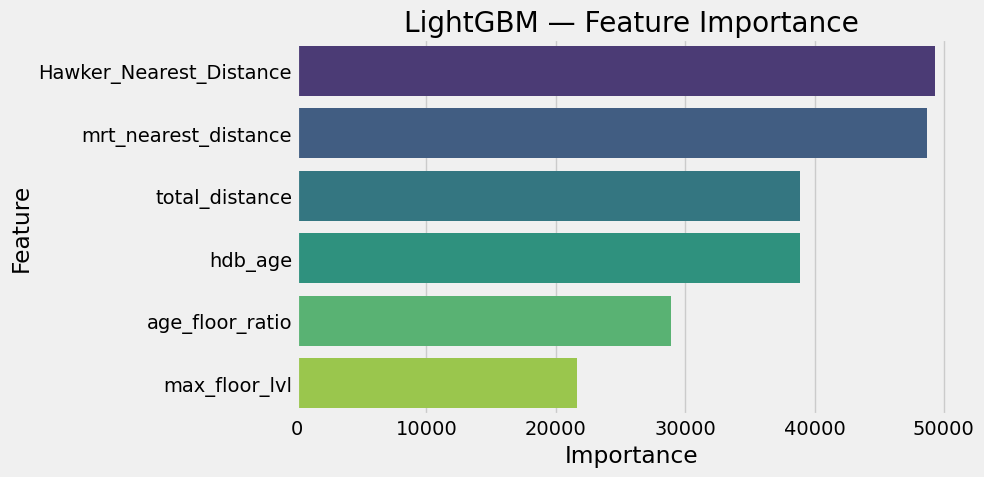

Feature Importance:
                Feature  Importance
Hawker_Nearest_Distance       49311
   mrt_nearest_distance       48721
         total_distance       38881
                hdb_age       38871
        age_floor_ratio       28929
          max_floor_lvl       21653


In [32]:

# Feature importance — LightGBM
if globals().get('lgbm_results') is not None:
    lgbm_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': lgbm_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('LightGBM — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(lgbm_importance.to_string(index=False))


---

## Step 11: XGBoost Model

Gradient boosting with level-wise tree growth and built-in regularisation (L1/L2).  
No feature scaling required — XGBoost is scale-invariant.


In [33]:

# ========== XGBOOST ==========
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS,          # Number of boosting trees (more trees can improve fit but increase training time)
        learning_rate=0.05,        # Step size shrinkage per tree (lower = slower but often more stable learning)
        max_depth=6,               # Maximum depth of each tree (controls model complexity)
        subsample=0.9,             # Fraction of training rows sampled per tree (adds randomness, helps reduce overfitting)
        colsample_bytree=0.9,      # Fraction of features sampled per tree (reduces correlation between trees)
        objective='multi:softmax', # Multiclass objective that outputs class labels directly
        num_class=len(TARGET_MAPPING),  # Total number of target classes for multiclass training
        random_state=RANDOM_STATE, # Reproducibility: same random seed gives same results
        n_jobs=-1,                 # Use all CPU cores for faster training
        eval_metric='mlogloss'     # Evaluation metric: multiclass log loss (lower is better)
    )
    xgb_results = evaluate_classification_model(
        xgb_model, X_train, X_test, y_train, y_test,
        'XGBoost', class_names
    )
    display_classification_results(xgb_results)
else:
    print("XGBoost is not installed. Run:  pip install xgboost")
    xgb_results = None


  MODEL: XGBoost
  Train Accuracy : 0.9833   |   Train Error : 0.0167
  Test  Accuracy : 0.9638   |   Test  Error : 0.0362



Classification Report — XGBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.98      0.94      0.96       775
          BEDOK       0.97      0.90      0.94      1077
         BISHAN       0.96      0.95      0.95       311
    BUKIT BATOK       0.99      0.99      0.99       688
    BUKIT MERAH       0.99      0.93      0.96       657
  BUKIT PANJANG       0.93      0.97      0.95       633
    BUKIT TIMAH       0.97      1.00      0.99        35
   CENTRAL AREA       0.95      1.00      0.97       144
  CHOA CHU KANG       1.00      1.00      1.00       653
       CLEMENTI       0.94      1.00      0.97       423
        GEYLANG       0.93      0.96      0.95       499
        HOUGANG       0.94      0.94      0.94       825
    JURONG EAST       0.89      0.98      0.93       364
    JURONG WEST       0.99      0.97      0.98      1349
KALLANG/WHAMPOA       0.98      0.95      0.97       478
  MARINE PARADE       1.00      1.00      1.00       1

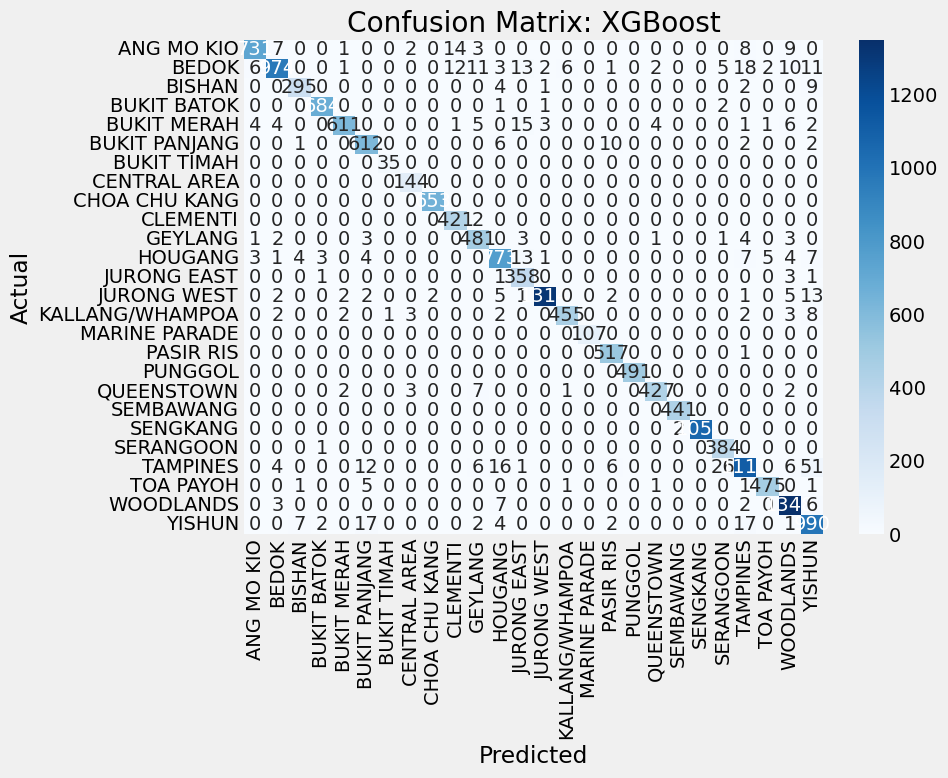

In [34]:

# Detailed Classification Report — XGBoost
if globals().get('xgb_results') is not None:
    print("Classification Report — XGBoost:")
    print("=" * 90)
    print(xgb_results['classification_report'])
    print("=" * 90)

    cm_xgb = xgb_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: XGBoost')
    plt.tight_layout()
    plt.show()


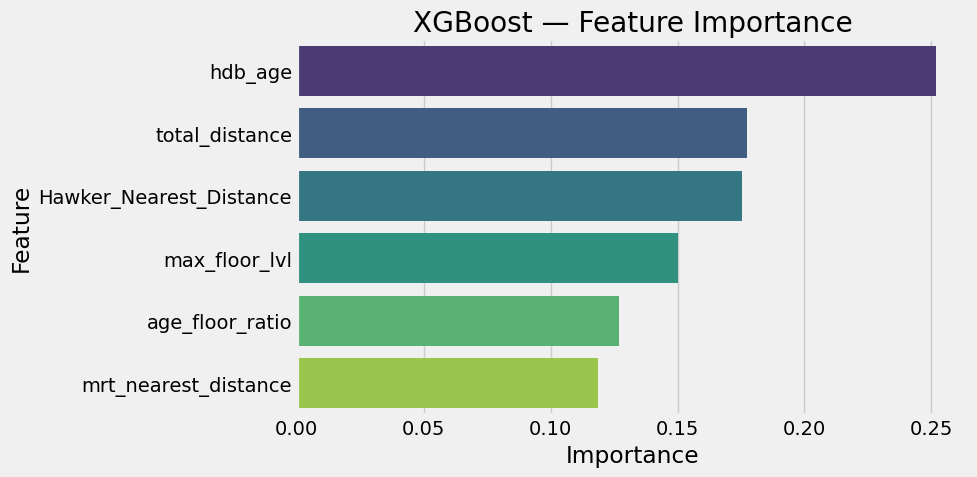

Feature Importance:
                Feature  Importance
                hdb_age    0.251863
         total_distance    0.177347
Hawker_Nearest_Distance    0.175222
          max_floor_lvl    0.150063
        age_floor_ratio    0.126941
   mrt_nearest_distance    0.118564


In [35]:

# Feature importance — XGBoost
if globals().get('xgb_results') is not None:
    xgb_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': xgb_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('XGBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(xgb_importance.to_string(index=False))


---

## Step 12: CatBoost Model

Gradient boosting with built-in handling for class imbalance.  
No feature scaling required — CatBoost is scale-invariant.


In [36]:

# ========== CATBOOST ==========
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train, X_test, y_train, y_test,
        'CatBoost', class_names
    )
    display_classification_results(catboost_results)
else:
    print("CatBoost is not installed. Run:  pip install catboost")
    catboost_results = None


  MODEL: CatBoost
  Train Accuracy : 0.8892   |   Train Error : 0.1108
  Test  Accuracy : 0.8331   |   Test  Error : 0.1669



Classification Report — CatBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.79      0.84      0.82       775
          BEDOK       0.87      0.65      0.74      1077
         BISHAN       0.68      0.90      0.78       311
    BUKIT BATOK       0.92      0.93      0.93       688
    BUKIT MERAH       0.88      0.76      0.82       657
  BUKIT PANJANG       0.73      0.84      0.78       633
    BUKIT TIMAH       0.64      1.00      0.78        35
   CENTRAL AREA       0.80      1.00      0.89       144
  CHOA CHU KANG       0.97      0.94      0.95       653
       CLEMENTI       0.72      0.91      0.80       423
        GEYLANG       0.74      0.82      0.78       499
        HOUGANG       0.75      0.71      0.73       825
    JURONG EAST       0.61      0.90      0.73       364
    JURONG WEST       0.92      0.72      0.81      1349
KALLANG/WHAMPOA       0.89      0.81      0.85       478
  MARINE PARADE       1.00      1.00      1.00       

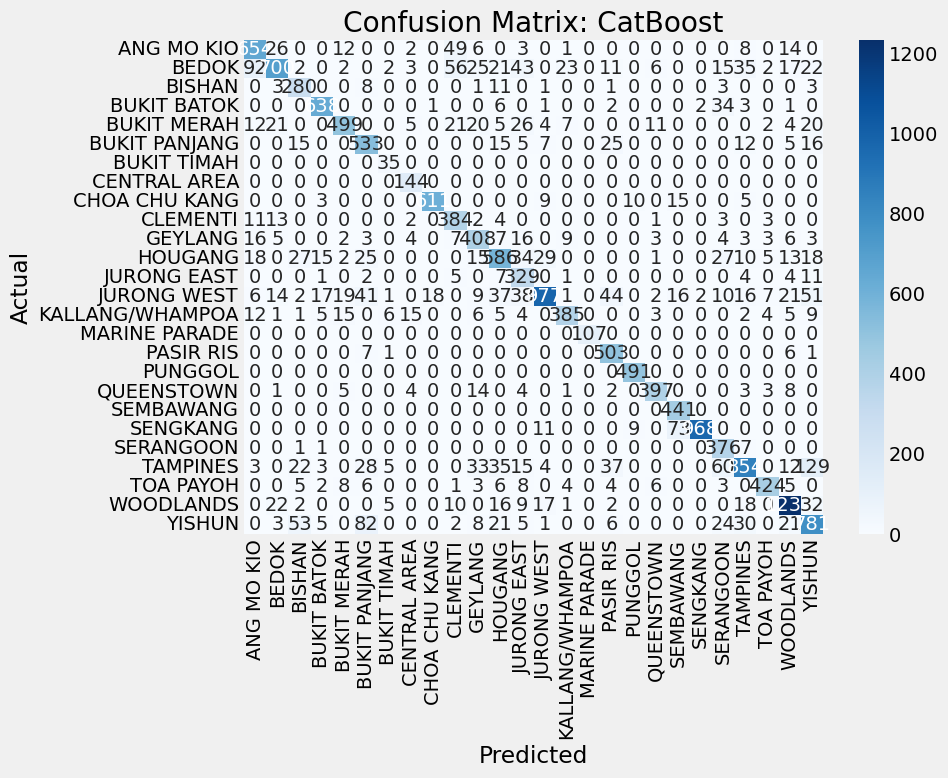

In [37]:

# Detailed Classification Report — CatBoost
if globals().get('catboost_results') is not None:
    print("Classification Report — CatBoost:")
    print("=" * 90)
    print(catboost_results['classification_report'])
    print("=" * 90)

    cm_catboost = catboost_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: CatBoost')
    plt.tight_layout()
    plt.show()


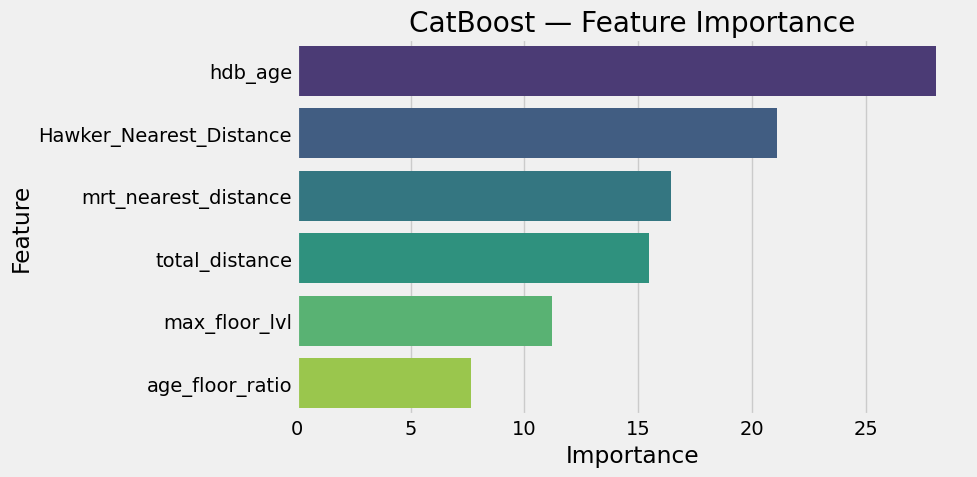

Feature Importance:
                Feature  Importance
                hdb_age   28.093350
Hawker_Nearest_Distance   21.099772
   mrt_nearest_distance   16.446408
         total_distance   15.481785
          max_floor_lvl   11.217728
        age_floor_ratio    7.660957


In [38]:

# Feature importance — CatBoost
if globals().get('catboost_results') is not None:
    catboost_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': catboost_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('CatBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(catboost_importance.to_string(index=False))


---

## Step 13: Model Comparison Summary

Rank all trained models side-by-side on the same train/test split.


In [39]:

# Collect all trained model results for comparison.
# KNN metrics come from the variables produced in Steps 6-7.
knn_train_acc = knn_final.score(X_train_scaled, y_train)
knn_test_acc  = knn_final.score(X_test_scaled,  y_test)

all_comparison_results = [
    {
        'Model':          f'KNN (k={best_k})',
        'Train Accuracy': knn_train_acc,
        'Test Accuracy':  knn_test_acc,
        'Train Error':    1 - knn_train_acc,
        'Test Error':     1 - knn_test_acc,
    },
    rf_results,
]

for res in [
    globals().get('lgbm_results'),
    globals().get('xgb_results'),
    globals().get('catboost_results'),
]:
    if res is not None:
        all_comparison_results.append(res)

comparison_df = pd.DataFrame([
    {
        'Model':          r['Model'],
        'Train Accuracy': round(r['Train Accuracy'], 4),
        'Test Accuracy':  round(r['Test Accuracy'],  4),
        'Train Error':    round(r['Train Error'],     4),
        'Test Error':     round(r['Test Error'],      4),
    }
    for r in all_comparison_results
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=" * 90)
print(f"                    MODEL COMPARISON SUMMARY ({len(comparison_df)} Models)")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 90)
print(f"  Best Predicting Model: {comparison_df.loc[0, 'Model']}")
print("=" * 90)

# Bar chart
# colors = ['#2ecc71' if m == comparison_df.loc[0, 'Model'] else '#3498db'
#           for m in comparison_df['Model']]

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].barh(comparison_df['Model'][::-1], comparison_df['Test Accuracy'][::-1],
#              color=colors[::-1], edgecolor='black')
# axes[0].set_xlabel('Test Accuracy')
# axes[0].set_title('Test Accuracy by Model')
# axes[0].set_xlim(0, 1.05)
# for i, acc in enumerate(comparison_df['Test Accuracy'][::-1]):
#     axes[0].text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10)

# axes[1].barh(comparison_df['Model'][::-1], comparison_df['Test Error'][::-1],
#              color=colors[::-1], edgecolor='black')
# axes[1].set_xlabel('Test Error')
# axes[1].set_title('Test Error by Model')
# axes[1].set_xlim(0, comparison_df['Test Error'].max() * 1.3 + 0.01)
# for i, err in enumerate(comparison_df['Test Error'][::-1]):
#     axes[1].text(err + 0.001, i, f'{err:.4f}', va='center', fontsize=10)

# plt.suptitle('Classification Model Comparison', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()


                    MODEL COMPARISON SUMMARY (5 Models)
        Model  Train Accuracy  Test Accuracy  Train Error  Test Error
Random Forest          1.0000         0.9964       0.0000      0.0036
    KNN (k=1)          1.0000         0.9962       0.0000      0.0038
     LightGBM          1.0000         0.9959       0.0000      0.0041
      XGBoost          0.9833         0.9638       0.0167      0.0362
     CatBoost          0.8892         0.8331       0.1108      0.1669

  Best Predicting Model: Random Forest


---

## Step 14: Confusion Matrix Gallery

Visualise class-level prediction behaviour for every model on the same test set.  
Each cell shows how many samples of each actual town were predicted as each other town.


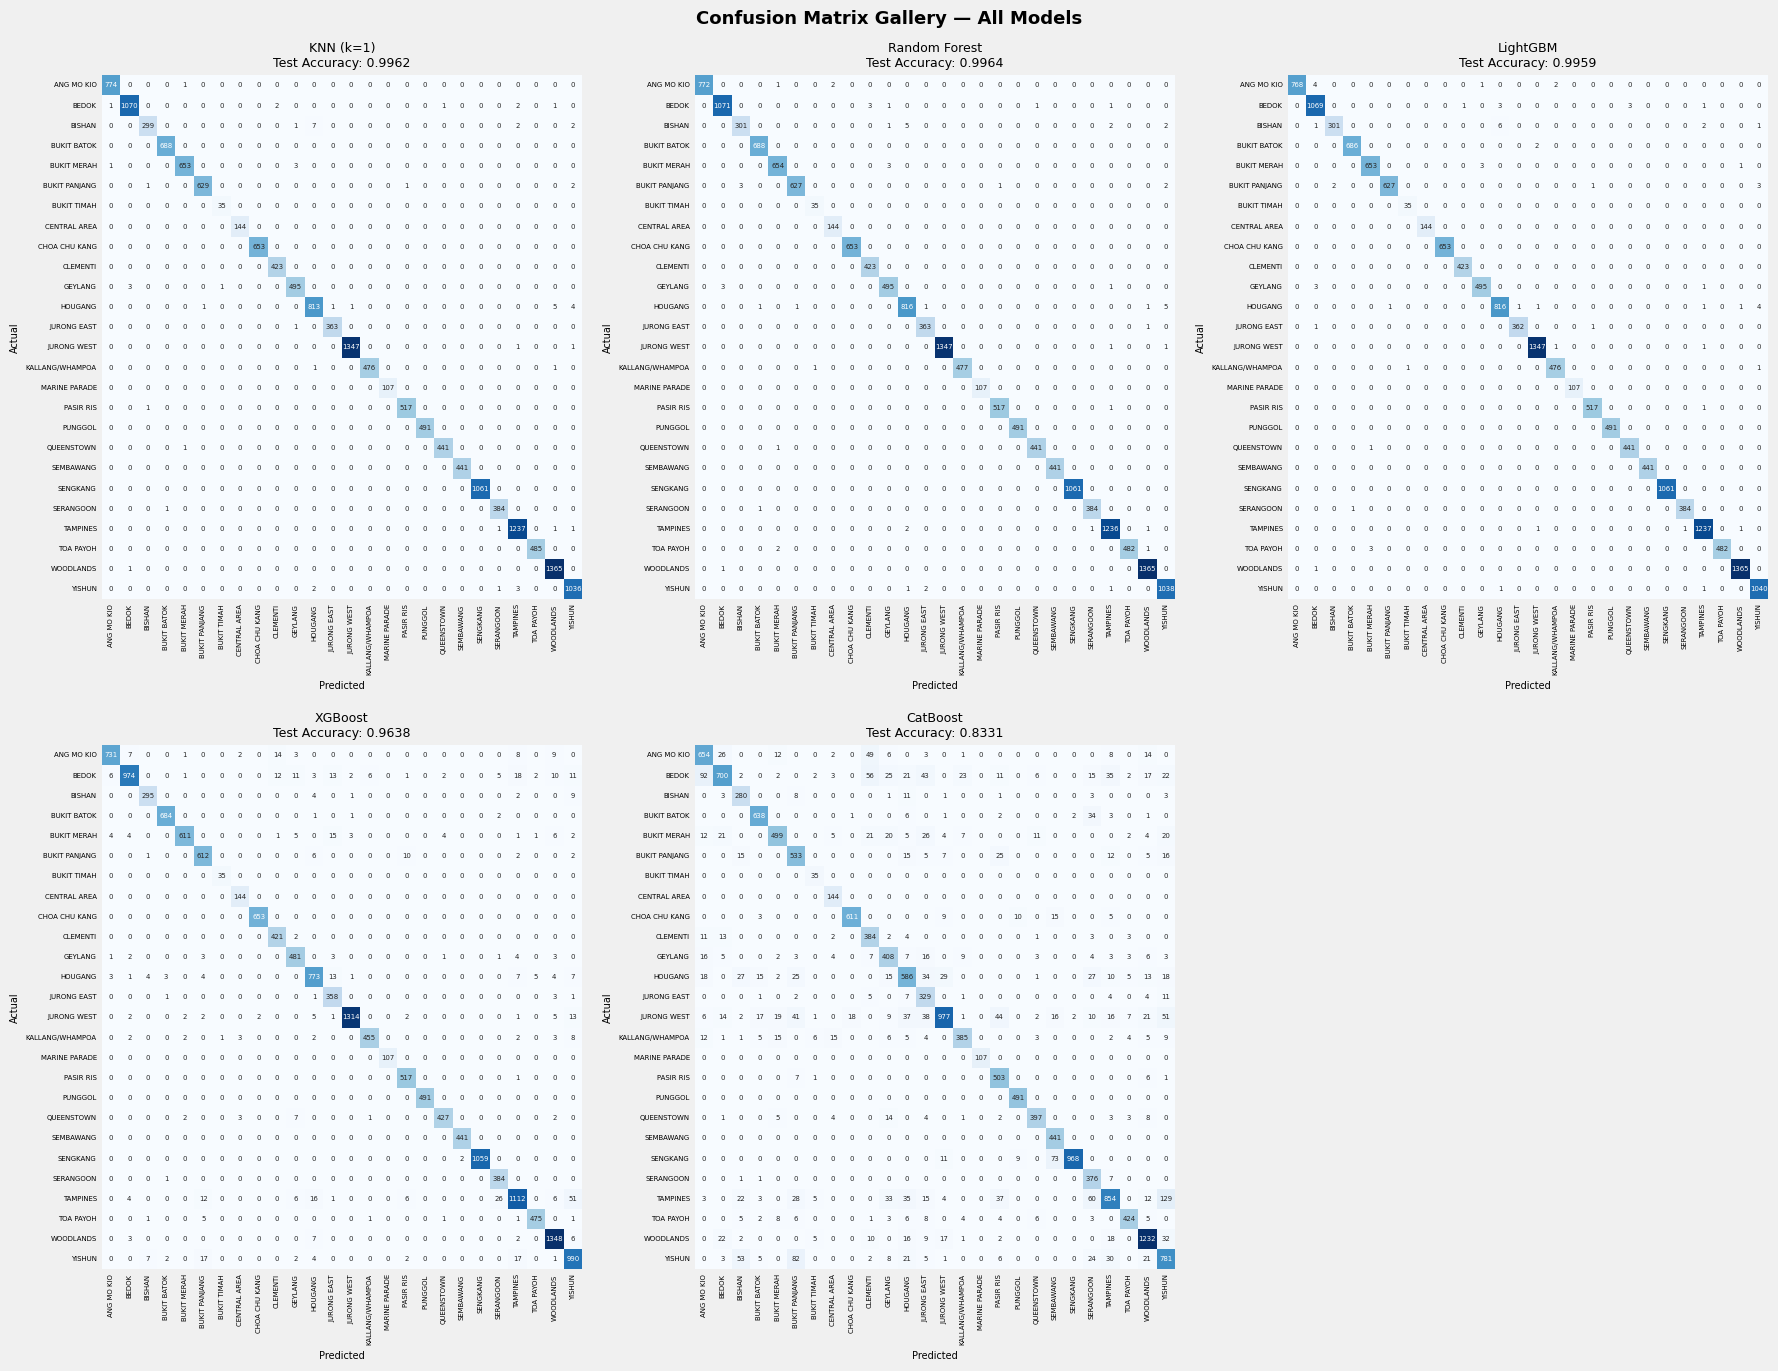

In [40]:

# Side-by-side confusion matrix gallery for all available models.
# Patch in KNN from the variables produced in Steps 6-7.
gallery_results = [
    {
        'Model':            f'KNN (k={best_k})',
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    },
    rf_results,
]

for res in [
    globals().get('lgbm_results'),
    globals().get('xgb_results'),
    globals().get('catboost_results'),
]:
    if res is not None:
        gallery_results.append(res)

n_models = len(gallery_results)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 7 * n_rows))
axes_flat = np.array(axes).flatten()

for idx, res in enumerate(gallery_results):
    ax   = axes_flat[idx]
    cm_i = res['confusion_matrix']
    sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={'size': 5})
    acc_i = cm_i.diagonal().sum() / cm_i.sum()
    ax.set_title(f"{res['Model']}\nTest Accuracy: {acc_i:.4f}", fontsize=9)
    ax.set_xlabel('Predicted', fontsize=7)
    ax.set_ylabel('Actual',    fontsize=7)
    ax.tick_params(axis='both', labelsize=5)

for j in range(len(gallery_results), len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Confusion Matrix Gallery — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Summary

| Step | Model | Type | Notes |
|------|-------|------|-------|
| Step 6–7 | KNN | Distance-based | Tuned via K search; requires feature scaling via Pipeline |
| Step 9   | Random Forest | Ensemble | 300 trees; balanced class weights; scale-invariant |
| Step 10  | LightGBM | Gradient Boosting | Fast leaf-wise growth; scale-invariant |
| Step 11  | XGBoost | Gradient Boosting | Level-wise with regularisation; scale-invariant |
| Step 12  | CatBoost | Gradient Boosting | Handles class imbalance; scale-invariant |
| Step 13  | Comparison | — | All models ranked on the same train/test split |
| Step 14  | Gallery | — | Confusion matrix per model for visual error analysis |

**How to reuse this notebook on a new dataset:**
1. Update `TARGET_COLUMN` and `DATA_PATH` in Steps 1–2
2. Adjust `FEATURE_COLUMNS` in Step 5b (and feature engineering in Step 3.5)
3. Re-run all cells — Steps 6–14 train and compare all models automatically
